# Exploratory Data Analysis

This section provides an overview of the data used in the project. It includes:

1. Data preprocessing
2. Data visualization
3. Data analysis
4. Data exploration

Pipeline is inspired by [astroNN](https://github.com/henrysky/astroNN/blob/master/demo_tutorial/galaxy10/Galaxy10_Tutorial.ipynb).

In [1]:
# install requirements

# if connected to colab

if 'google.colab' in str(get_ipython()):
  print('running on colab')
  !git clone https://github.com/ongarileonardo/galaxy_class.git
  %cd galaxy_class

%pip install -r requirements.txt

  Cloning https://github.com/henrysky/astroNN.git to /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-lwl1r_2s
  Running command git clone --filter=blob:none --quiet https://github.com/henrysky/astroNN.git /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-lwl1r_2s
  Resolved https://github.com/henrysky/astroNN.git to commit 6d947193f5a995c61266d3702b3a2df4643489f5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# import everything we need first
from keras import utils
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from astroNN.models import Galaxy10CNN
from astroNN.datasets import galaxy10
from astroNN.datasets.galaxy10 import galaxy10cls_lookup, galaxy10_confusion

In [25]:
# To load images and labels (will download automatically at the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = galaxy10.load_data()

/Users/leo/.astroNN/datasets/Galaxy10_DECals.h5 was found!


In [ ]:
labels

array([0, 0, 0, ..., 9, 9, 9], dtype=uint8)

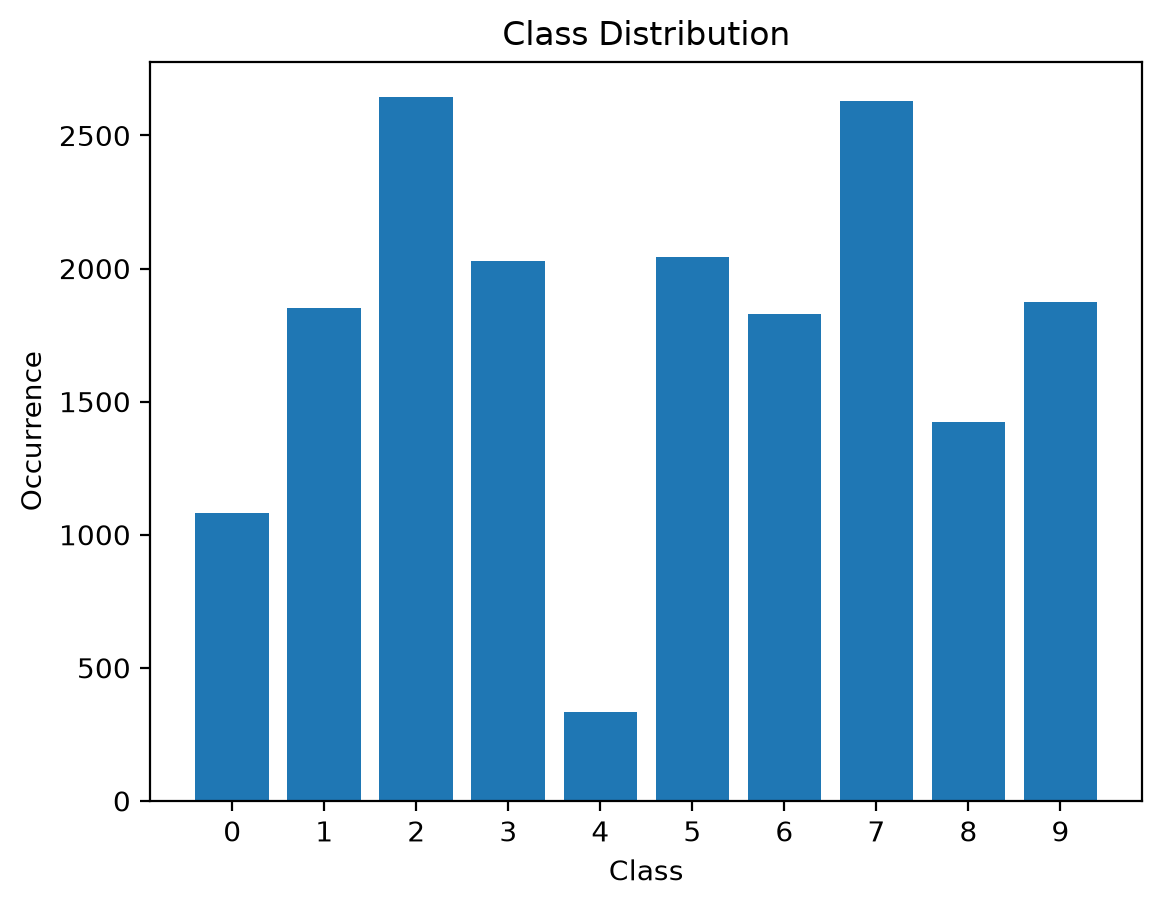

In [5]:
counts = np.bincount(labels)
plt.bar(range(len(counts)), counts)
plt.xlabel("Class")
plt.ylabel("Occurrence")
plt.xticks(range(len(counts)))
plt.title("Class Distribution")
plt.show()

In [27]:
# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# (one hot encoding)
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [7]:
# # Select 10 of the images to inspect
# img = None
# plt.ion()
# print("===================Data Inspection===================")
# for counter, i in enumerate(
#     range(np.random.randint(0, labels.shape[0], size=10).shape[0])
# ):
#     img = plt.imshow(images[i])
#     plt.title(
#         f"Class {np.argmax(labels[i])}: {galaxy10cls_lookup(labels[i])} \n Random Demo images {counter+1} of 10"
#     )
#     plt.draw()
#     plt.pause(2.0)
# plt.close("all")
# print("===============Data Inspection Finished===============")

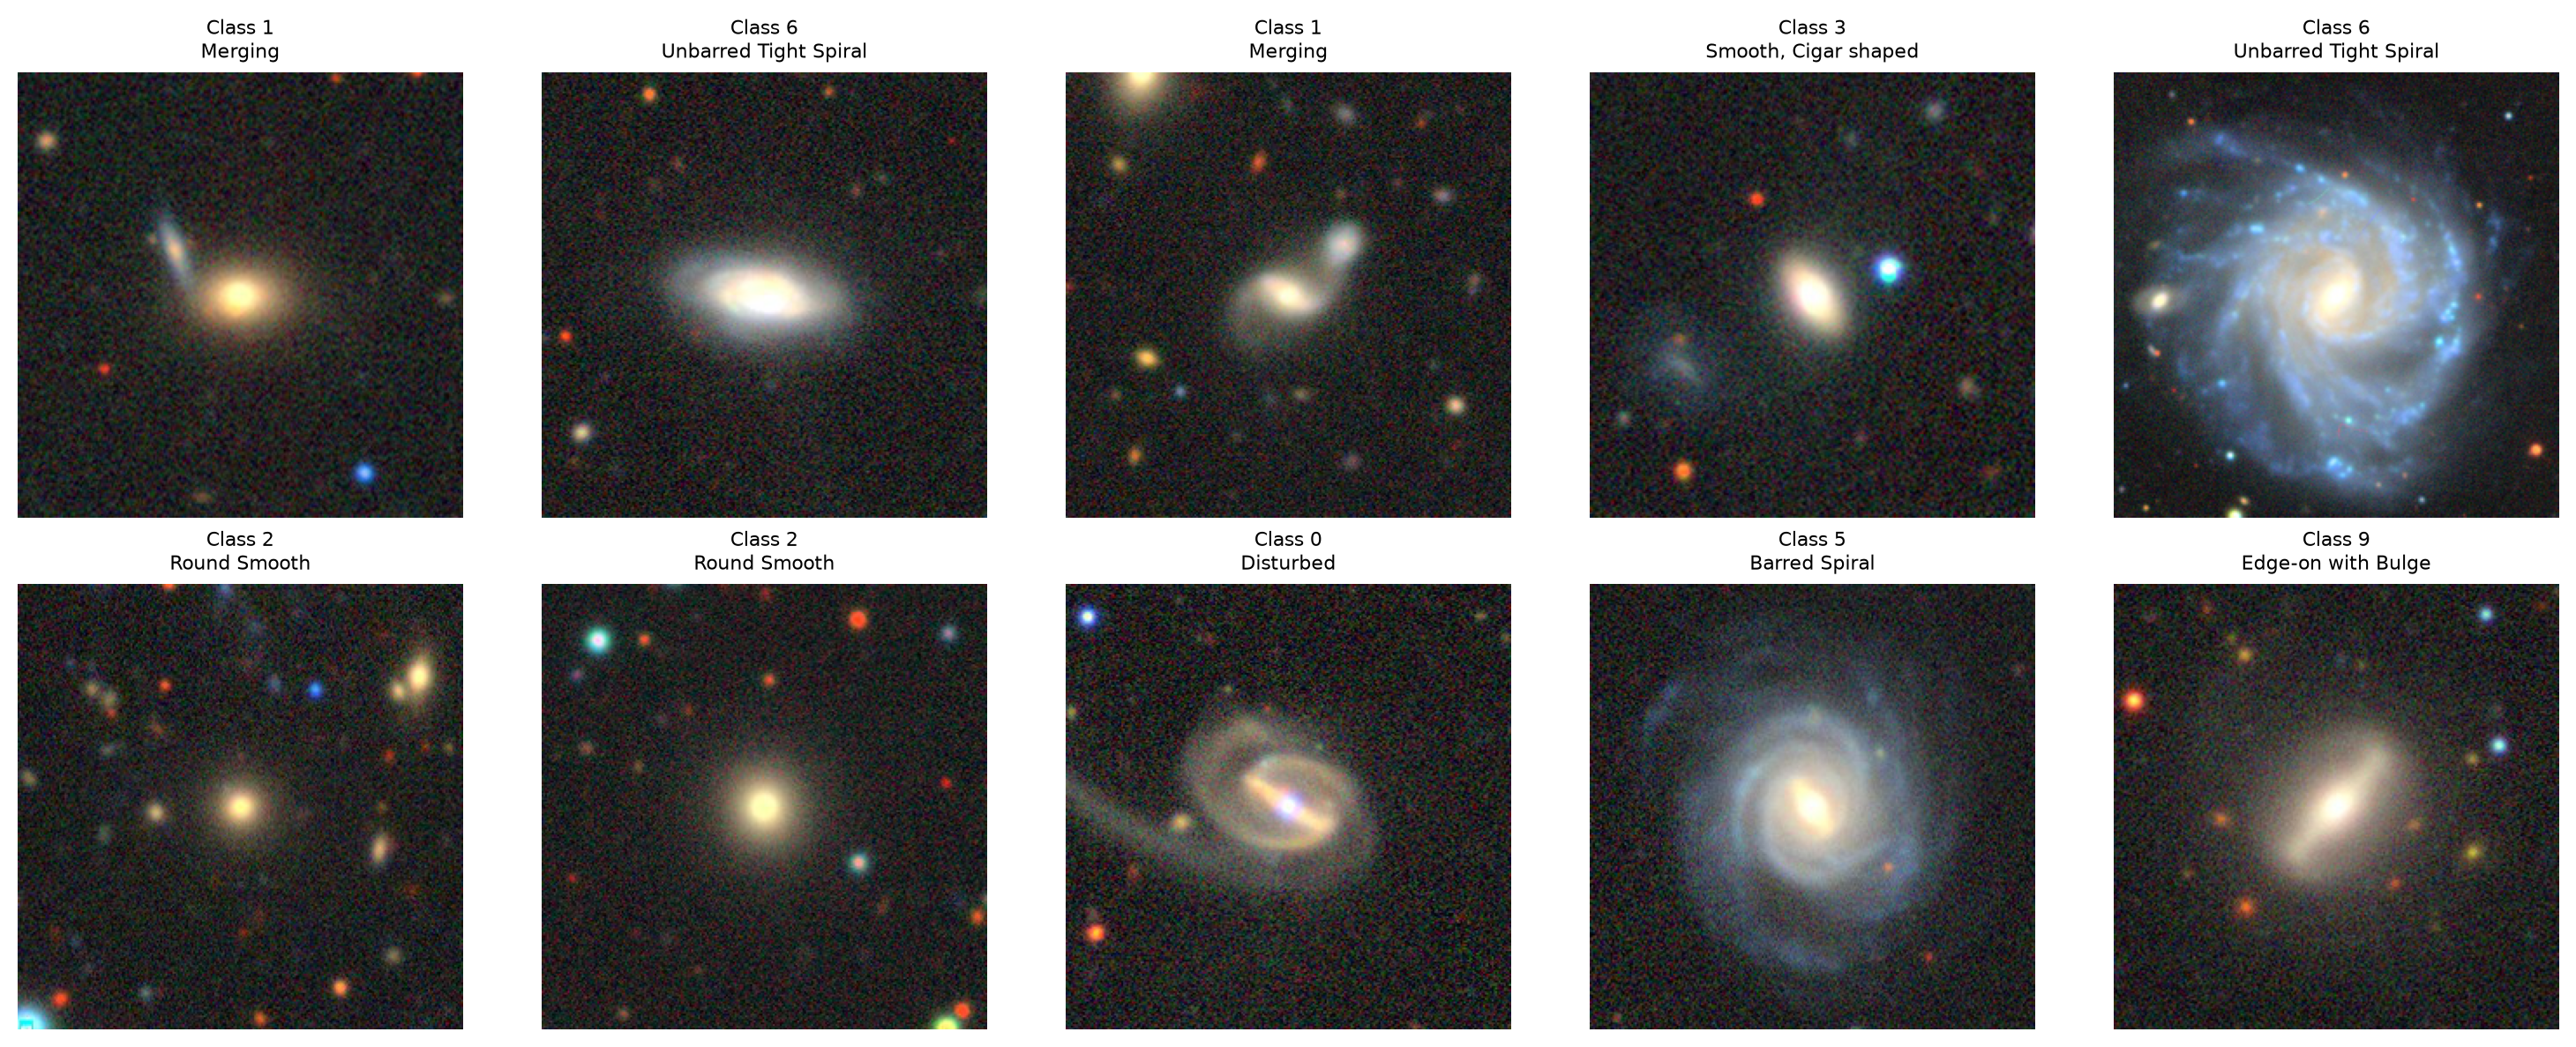

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, labels.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(images[i])
    ax.set_title(f"Class {np.argmax(labels[i])}\n{galaxy10cls_lookup(labels[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("galaxies.pdf")
plt.show()

In [10]:
def center_crop(img, crop_size):
    h, w = img.shape[:2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

crop_size = 128
images_small = np.array([center_crop(img, crop_size) for img in images])
print(images_small.shape, images_small.nbytes / 1e9, "GB")

(17736, 128, 128, 3) 0.871759872 GB


In [11]:
# from PIL import Image
# import numpy as np

# images_gray = np.array([
#     np.array(Image.fromarray(img).convert('L')) for img in images
# ])

# print(images_gray.shape)  

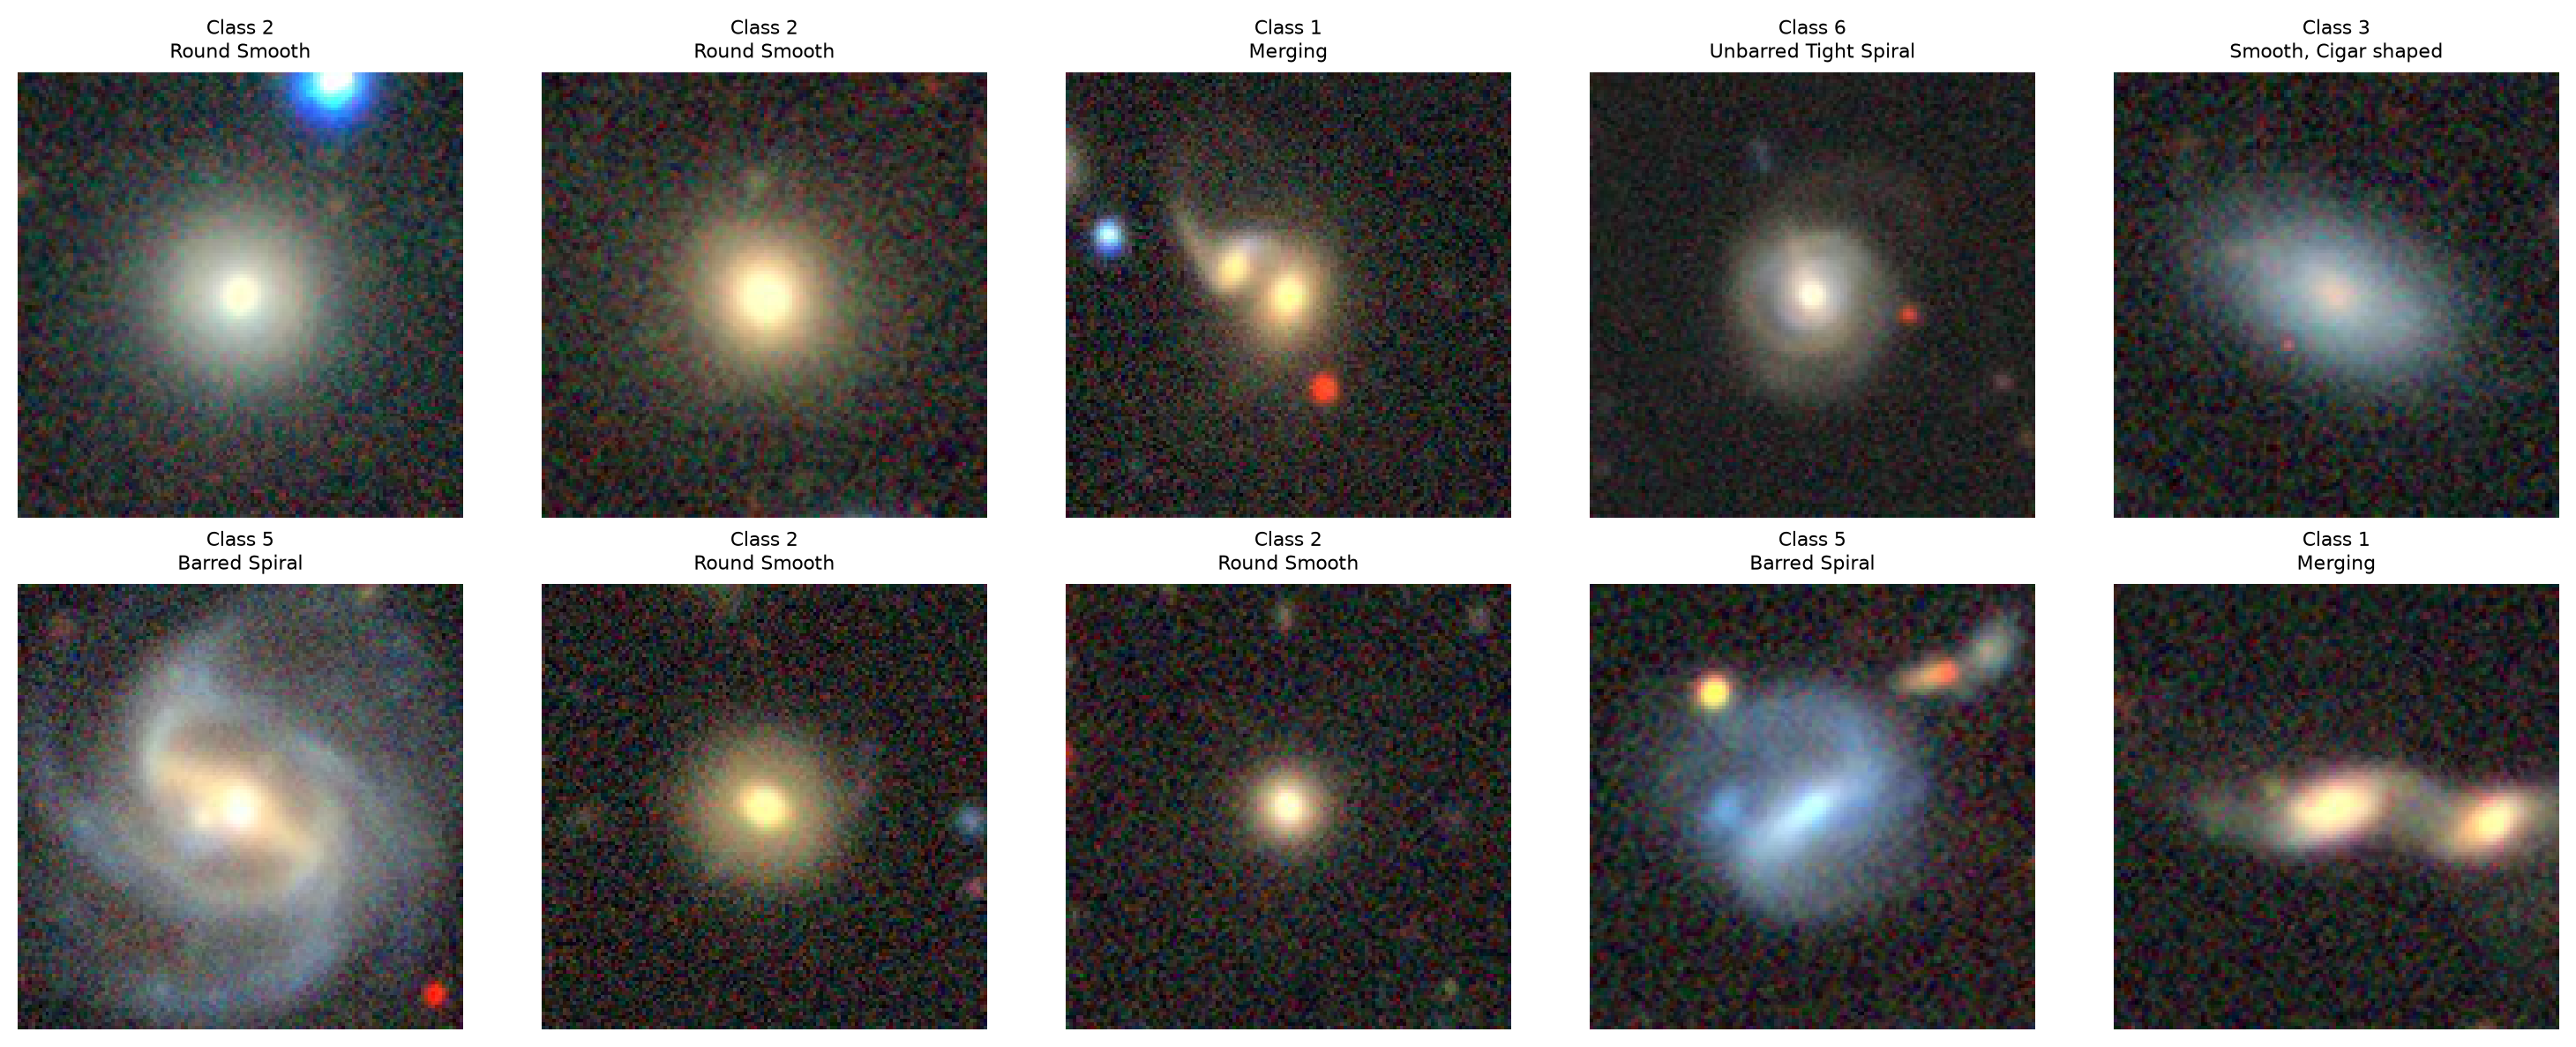

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, labels.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(images_small[i])
    ax.set_title(f"Class {np.argmax(labels[i])}\n{galaxy10cls_lookup(labels[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
print("images shape:", images_small.shape, images_small.dtype)
print("labels shape:", labels.shape, labels.dtype)
print("Estimated memory (GB):", images.nbytes / 1e9)

import psutil
print("RAM available (GB):", psutil.virtual_memory().available / 1e9)
print("RAM total (GB):", psutil.virtual_memory().total / 1e9)

images shape: (17736, 128, 128, 3) uint8
labels shape: (17736, 10) float64
Estimated memory (GB): 3.487039488
RAM available (GB): 1.20832
RAM total (GB): 8.589934592


In [14]:
del images

In [15]:
# Split the dataset into training set and testing set
train_idx, test_idx = train_test_split(np.arange(labels.shape[0]), test_size=0.1)
train_images, train_labels, test_images, test_labels = (
    images_small[train_idx],
    labels[train_idx],
    images_small[test_idx],
    labels[test_idx],
)

del images_small, labels

In [16]:
train_images = train_images.astype(np.float32, copy=False)

In [17]:
train_labels = train_labels.astype(np.float32, copy=False)

In [18]:
test_images = test_images.astype(np.float32, copy=False)

In [19]:
test_labels = test_labels.astype(np.float32, copy=False)

In [20]:
# To create a neural network instance
galaxy10net = Galaxy10CNN()

# set maximium epochs the neural network can run, set 5 to get quick result
galaxy10net.max_epochs = 5

# To train the nerual net
# astroNN will normalize the data by default
galaxy10net.fit(train_images, train_labels)

# print model summary 
galaxy10net.keras_model.summary()

Number of Training Data: 14366, Number of Validation Data: 1596
====Message from Normalizer====
You selected mode: 255
Featurewise Center: {'input': False}
Datawise Center: {'input': False} 
Featurewise std Center: {'input': False}
Datawise std Center: {'input': False} 
====Message ends====
====Message from Normalizer====
You selected mode: 0
Featurewise Center: {'output': False}
Datawise Center: {'output': False} 
Featurewise std Center: {'output': False}
Datawise std Center: {'output': False} 
====Message ends====
Epoch 1/5


/Users/leo/Documents/github/galaxy_class/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: input. Received: the structure of inputs={'input': '*'}
  warnings.warn(


224/224 - 63s - 280ms/step - categorical_accuracy: 0.2087 - loss: 2.4137 - val_categorical_accuracy: 0.2871 - val_loss: 1.9743 - learning_rate: 0.0050
Epoch 2/5
224/224 - 2352s - 10s/step - categorical_accuracy: 0.2754 - loss: 1.9630 - val_categorical_accuracy: 0.2936 - val_loss: 1.9108 - learning_rate: 0.0050
Epoch 3/5
224/224 - 63s - 279ms/step - categorical_accuracy: 0.3018 - loss: 1.8774 - val_categorical_accuracy: 0.3340 - val_loss: 1.8309 - learning_rate: 0.0050
Epoch 4/5
224/224 - 58s - 260ms/step - categorical_accuracy: 0.3080 - loss: 1.8473 - val_categorical_accuracy: 0.3333 - val_loss: 1.7964 - learning_rate: 0.0050
Epoch 5/5
224/224 - 56s - 252ms/step - categorical_accuracy: 0.3114 - loss: 1.8236 - val_categorical_accuracy: 0.3470 - val_loss: 1.7385 - learning_rate: 0.0050
Completed Training, 2593.96s in total


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Activation)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,690,416 (48.41 MB)

 Trainable params: 4,230,138 (16.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,460,278 (32.27 MB)

Prediction progress:  11%|███████▏                                                          | 192/1774 [00:00<00:01, 1556.54sample/s]/Users/leo/Documents/github/galaxy_class/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: input. Received: the structure of inputs={'input': '*'}
  warnings.warn(
Prediction progress: : 1838sample [00:02, 906.16sample/s]                                                                            


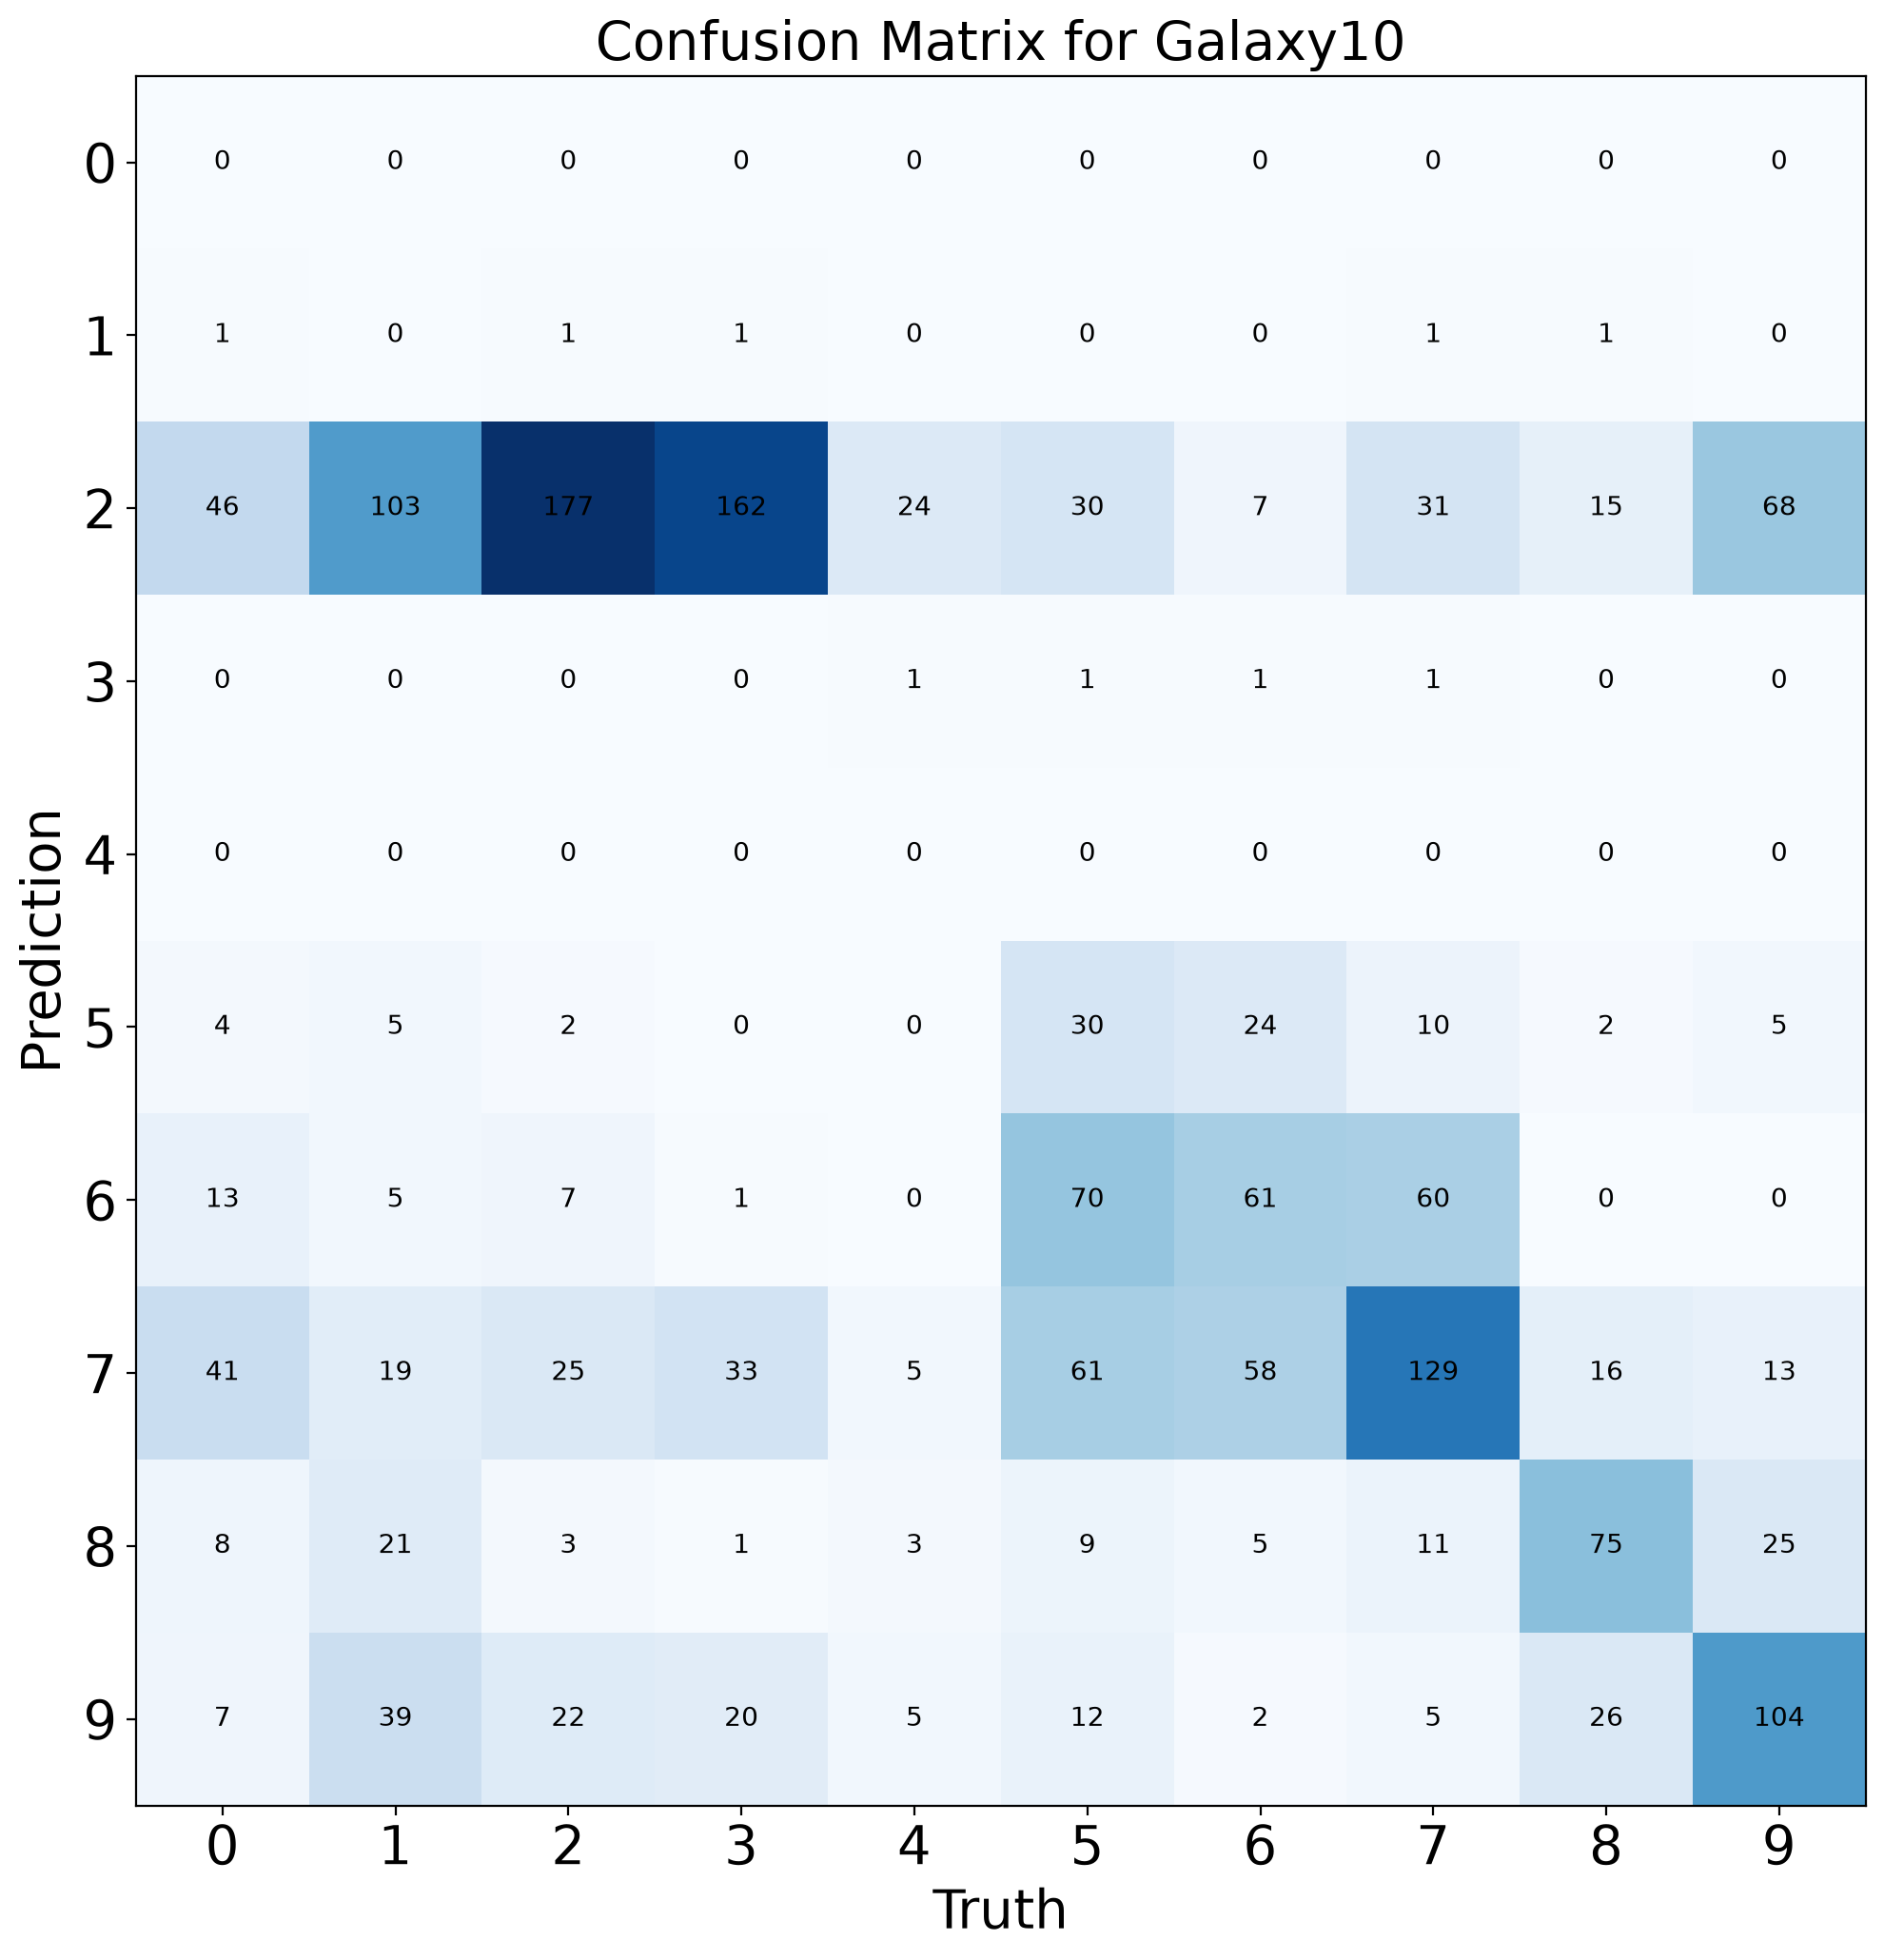

In [22]:
# After the training, you can test the neural net performance
# Please notice predicted_labels are labels predicted from neural network. test_labels are ground truth from the dataset
predicted_labels = galaxy10net.predict(test_images)

# Convert predicted_labels to class
prediction_class = np.argmax(predicted_labels, axis=1)

# Convert test_labels to class
test_class = np.argmax(test_labels, axis=1)

# Prepare a confusion matrix
confusion_matrix = np.zeros((10, 10))

# create the confusion matrix
for counter, i in enumerate(prediction_class):
    confusion_matrix[i, test_class[counter]] += 1

# Plot the confusion matrix
galaxy10_confusion(confusion_matrix)